#week04 / titanic

202433638_장영환

#고려사항
1. lable encoding
2. 결측치 확인 & 제거
3. outlier(이상치) 개수 확인
4. feature selection

#진행과정
1차적으로 결측치 확인 후 제거 열 결정

2차적으로는 문자형 feature 숫자로 변경


궁극적으로 feature selection 진행한 데이터와 아닌 데이터 모델 성능 비교

#변수정의
PassengerId: 승객의 고유 아이디

Survived: 생존 여부. 0은 사망, 1은 생존

Pclass: 티켓의 클래스. 1은 1등석, 2는 2등석, 3은 3등석

Name: 승객의 이름

Sex: 승객의 성별

Age: 승객의 나이

SibSp: 함께 탑승한 형제자매 또는 배우자의 수

Parch: 함께 탑승한 부모 또는 자녀의 수

Ticket: 티켓 번호

Fare: 승객이 지불한 요금

Cabin: 승객이 머무른 객실 번호

Embarked: 승객이 탑승한 항구. C는 Cherbourg, Q는 Queenstown, S는 Southampton을 의미.

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

path = '/content/drive/MyDrive/Colab Notebooks/인공지능개론/week04/titanic.csv'
df = pd.read_csv(path)

In [37]:
print("결측치 개수 확인:")
df.isnull().sum()

결측치 개수 확인:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


결과 상 Age, cabin에서 높은 결측치를 기록

* Age에서 null값은 평균값으로 대체
* cabin은 결측치가 너무 많음으로 열 삭제 (단 결측이 많아도 “객실 정보 있음/없음”과 “대략 어느 구역인지”를 반영 가능함으로 충분히 고려해봐야한다.)
* Embarked의 null 값은 최빈 값으로 대체

In [38]:
# 결측치 처리

df.fillna({  #fillna()는 df안의 결측치를 대체하는 함수
    'Age': df['Age'].mean(),
    'Embarked': df['Embarked'].mode()[0]
}, inplace=True)

df = df.drop('Cabin',axis=1)

In [39]:
#lable encoding

df['Sex'] = df['Sex'].replace({"male" : 0, "female" : 1 })
df['Embarked'] = df['Embarked'].replace({"C" : 0, "Q" : 1, "S" : 2 })
print(df['Sex'], df['Embarked']) #int64로 표시됨

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64 0      2
1      0
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    0
890    1
Name: Embarked, Length: 891, dtype: int64


/tmp/ipykernel_13007/2662030038.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({"male" : 0, "female" : 1 })
/tmp/ipykernel_13007/2662030038.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Embarked'] = df['Embarked'].replace({"C" : 0, "Q" : 1, "S" : 2 })


#이제 생존률 예측에 의미 없는 특성을 제거해보자
PassengerId / Name / Ticket


In [40]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,2
1,1,1,1,38.0,1,0,71.2833,0
2,1,3,1,26.0,0,0,7.9250,2
3,1,1,1,35.0,1,0,53.1000,2
4,0,3,0,35.0,0,0,8.0500,2


#상관관계 히트맵 분석

1에 가까움: 강한 양의 상관관계

-1에 가까움: 강한 음의 상관관계

0에 가까움: 상관관계가 약함

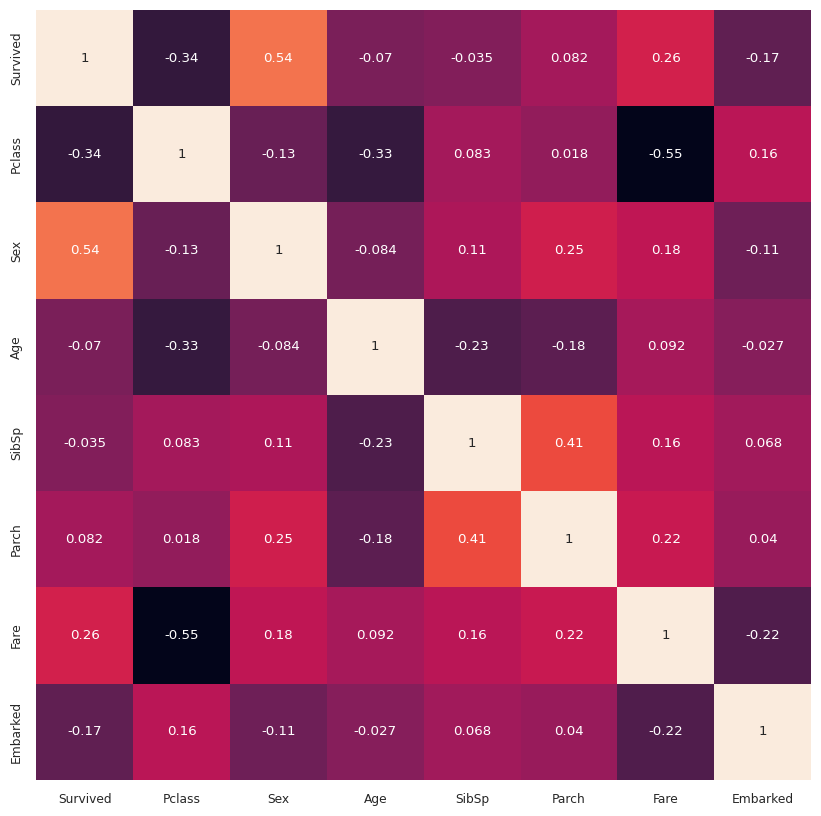

In [41]:
df_corr=df.corr()

plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

#시사점

Survived 와 Sex : 0.54 ->여성이 더 많이 생존

Survived 와 Pclass : -0.34 ->객실 등급이 낮아질 수록 생존 가능성이 낮아지는 경향

Survived 와 Fare : 0.26 -> 요금이 높을수록 생존 가능성이 조금 높아지는 경향

Survived 와 Embarked : -0.17 ->승선 항구에 따라 생존률 차이가 조금 있을 수 있지만, 영향은 크지 않은 편

나머지 요소들은 거의 영향이 없다 그러므로

1차 평가 / 전체요소로 모델링

2차평가 / sex, Pclass, Fare, Embarked으로 모델링 진행

1차 평가와 2차 평가 정확도 비교로 Feater selection 효과 비교분석

#1차 평가

In [42]:
#기본 세팅
y = df['Survived']
x = df.drop('Survived', axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(668, 7) (668,)
(223, 7) (223,)


In [54]:
#Logistic Regression
clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(x_train, y_train)
y_pred = clf_lr.predict(x_test)

print (accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

0.7937219730941704
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       139
           1       0.73      0.73      0.73        84

    accuracy                           0.79       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



In [55]:
# DecisionTree
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(x_train, y_train)

y_pred = clf_dt.predict(x_test)

print (accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

0.757847533632287
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       139
           1       0.68      0.68      0.68        84

    accuracy                           0.76       223
   macro avg       0.74      0.74      0.74       223
weighted avg       0.76      0.76      0.76       223



In [56]:
# RandomForest
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(x_train, y_train)

y_pred = rf_clf.predict(x_test)

print(accuracy_score(y_test,y_pred))
print(metrics.classification_report(y_test, y_pred))

0.8251121076233184
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       139
           1       0.79      0.73      0.76        84

    accuracy                           0.83       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.83      0.82       223



In [57]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)
from sklearn import metrics

scores = metrics.accuracy_score(y_test, y_pred)
print(scores)
print(metrics.classification_report(y_test, y_pred))

0.7309417040358744
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       139
           1       0.65      0.61      0.63        84

    accuracy                           0.73       223
   macro avg       0.71      0.71      0.71       223
weighted avg       0.73      0.73      0.73       223



#1차 평가 모델들의 정확도 평균 값

0.7769058295964126

#2차 평가

In [63]:
#기본 세팅
x = df[['Sex', 'Pclass', 'Fare', 'Embarked']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(668, 4) (668,)
(223, 4) (223,)


In [64]:
#Logistic Regression
clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(x_train, y_train)
y_pred = clf_lr.predict(x_test)

print (accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

0.7847533632286996
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       139
           1       0.69      0.79      0.73        84

    accuracy                           0.78       223
   macro avg       0.77      0.78      0.78       223
weighted avg       0.79      0.78      0.79       223



In [65]:
# DecisionTree
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(x_train, y_train)

y_pred = clf_dt.predict(x_test)

print (accuracy_score(y_test, y_pred))
print(metrics.classification_report(y_test, y_pred))

0.7982062780269058
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       139
           1       0.74      0.71      0.73        84

    accuracy                           0.80       223
   macro avg       0.79      0.78      0.78       223
weighted avg       0.80      0.80      0.80       223



In [66]:
# RandomForest
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(x_train, y_train)

y_pred = rf_clf.predict(x_test)

print(accuracy_score(y_test,y_pred))
print(metrics.classification_report(y_test, y_pred))

0.8161434977578476
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       139
           1       0.76      0.75      0.75        84

    accuracy                           0.82       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.82      0.82      0.82       223



In [67]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)
from sklearn import metrics

scores = metrics.accuracy_score(y_test, y_pred)
print(scores)
print(metrics.classification_report(y_test, y_pred))

0.757847533632287
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       139
           1       0.70      0.62      0.66        84

    accuracy                           0.76       223
   macro avg       0.74      0.73      0.74       223
weighted avg       0.75      0.76      0.75       223



#2차 평가 모델들의 정확도 평균 값

0.789237668161435

#결과

정확도 0.012331838565022402만큼의 상승

#추가적으로
해당 데이터상 Titanic의 Fare나 Age는 극단값이지만 실제 의미 있는 값이기에 이상치 제거 진행하지 않음